Loaded 8106 valid SMILES

Creating latent interpolation plot for FastChemTokenizerHF
Checkpoint vocab size: 1238, Current tokenizer vocab size: 1238
Model vocab size: 1238
Model loaded for FastChemTokenizerHF. Running smoke test...
Sample decoded SMILES: 
Classifying validity for dims 0, 1...
Classifying validity for dims 2, 3...
Classifying validity for dims 4, 5...
Classifying validity for dims 6, 7...
Classifying validity for z0, z1 with z2=-2...
Classifying validity for z0, z1 with z2=-1...
Classifying validity for z0, z1 with z2=1...
Classifying validity for z0, z1 with z2=2...
Saved plot to latent_space_plots/FastChemTokenizerHF_latent_interpolation.png


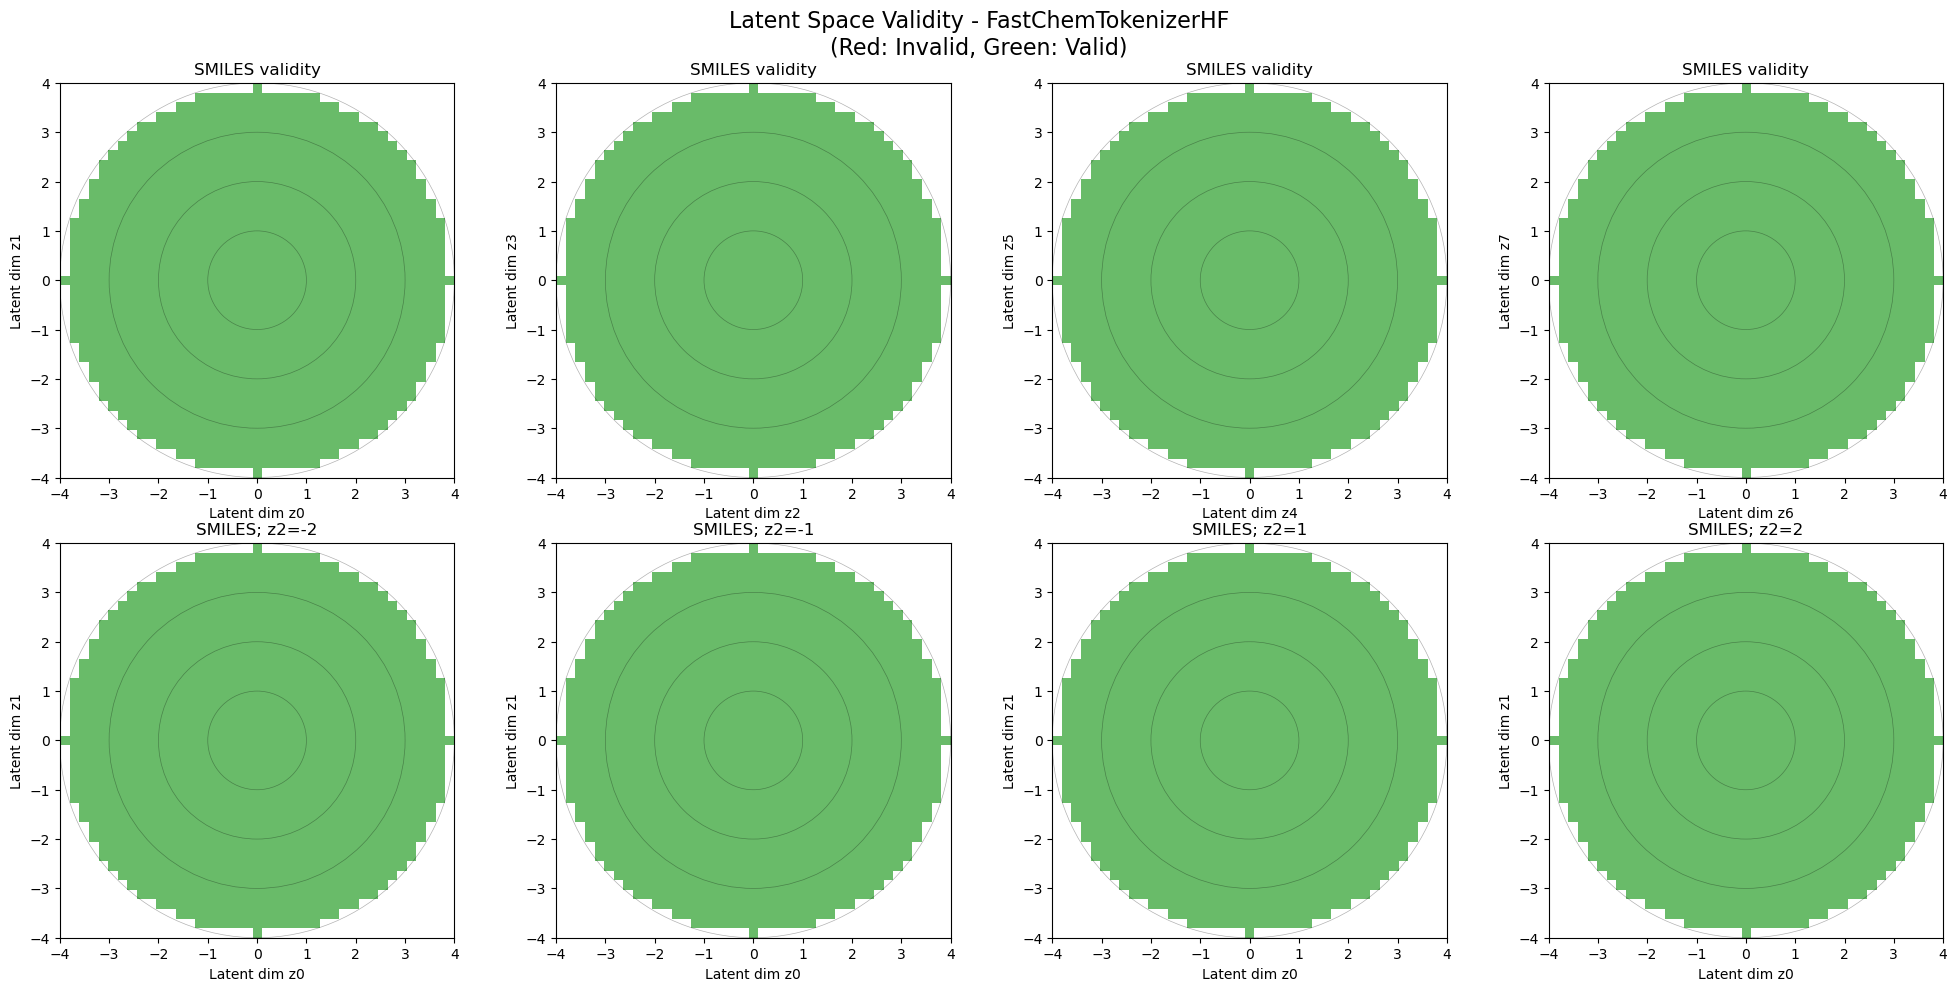


Creating latent interpolation plot for ChemBERTa
Checkpoint vocab size: 767, Current tokenizer vocab size: 767
Model vocab size: 767
Model loaded for ChemBERTa. Running smoke test...
Sample decoded SMILES: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
Classifying validity for dims 0, 1...
Classifying validity for dims 2, 3...
Classifying validity for dims 4, 5...
Classifying validity for dims 6, 7...
Classifying validity for z0, z1 with z2=-2...
Classifying validity for z0, z1 with z2=-1...
Classifying validity for z0, z1 with z2=1...
Classifying validity for z0, z1 with z2=2...
Saved plot to latent_space_plots/ChemBERTa_latent_interpolation.png


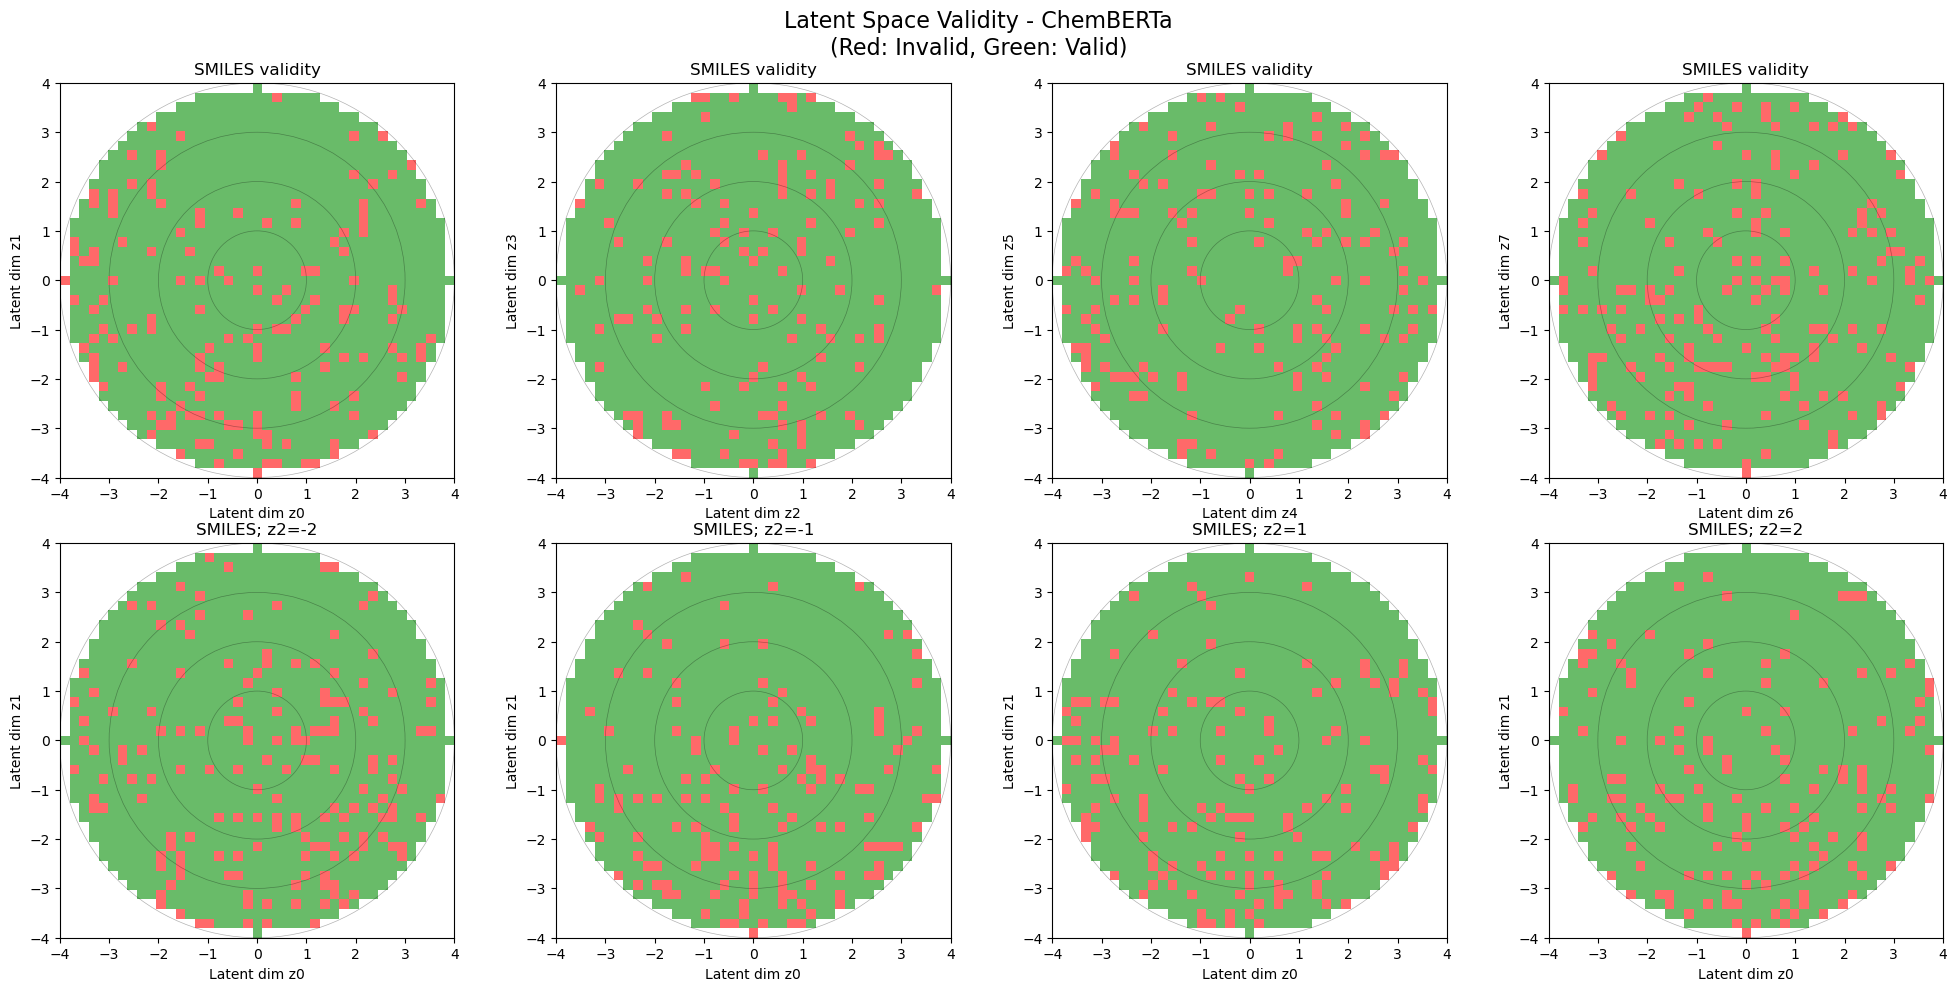

In [1]:
#!/usr/bin/env python3
"""
Latent Space Visualization for Molecule VAE Models
Only outputs latent interpolation plots (no t-SNE/PCA).
"""

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Import tokenizer
from transformers import AutoTokenizer
try:
    from FastChemTokenizerHF import FastChemTokenizer
except ImportError:
    print("FastChemTokenizer not found. Please ensure it's in your PYTHONPATH.")
    FastChemTokenizer = None

# Set seeds
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TokenizerWrapper:
    def __init__(self, tokenizer, name,
                 bos_token="<s>", eos_token="</s>",
                 pad_token="<pad>", unk_token="<unk>"):
        self.tokenizer = tokenizer
        self.name = name

        # Only call add_special_tokens if the tokenizer actually supports it
        if hasattr(tokenizer, "add_special_tokens") and callable(tokenizer.add_special_tokens):
            try:
                tokenizer.add_special_tokens({
                    "bos_token": bos_token,
                    "eos_token": eos_token,
                    "pad_token": pad_token,
                    "unk_token": unk_token,
                })
            except NotImplementedError:
                # Your FastChemTokenizerHF already defines these tokens internally
                pass

    def encode(self, smiles: str, add_special_tokens: bool = True):
        return self.tokenizer(
            smiles,
            add_special_tokens=add_special_tokens,
            return_attention_mask=False,
            return_tensors=None
        )

    def decode(self, token_ids, skip_special_tokens=True):
        return self.tokenizer.decode(token_ids, skip_special_tokens=skip_special_tokens)

    def __len__(self):
        return len(self.tokenizer)

    def get_vocab(self):
        return self.tokenizer.get_vocab()
    
    @property
    def bos_token_id(self):
        return self.tokenizer.bos_token_id

    @property
    def eos_token_id(self):
        return self.tokenizer.eos_token_id

    @property
    def pad_token_id(self):
        return self.tokenizer.pad_token_id

    @property
    def unk_token_id(self):
        return self.tokenizer.unk_token_id

def collate_fn(batch, tokenizer, max_length=128):
    encodings = [tokenizer.encode(s, add_special_tokens=True) for s in batch]
    input_ids = [e['input_ids'] for e in encodings]
    max_len = min(max(len(ids) for ids in input_ids), max_length)
    padded = []
    lengths = []
    pad_token_id = tokenizer.tokenizer.pad_token_id

    for ids in input_ids:
        if len(ids) > max_length:
            ids = ids[:max_length]
        else:
            ids = ids + [pad_token_id] * (max_len - len(ids))
        padded.append(ids)
        lengths.append(min(len(ids), max_length))

    return torch.tensor(padded, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

class SmilesDataset(Dataset):
    def __init__(self, smiles_list): self.smiles_list = smiles_list
    def __len__(self): return len(self.smiles_list)
    def __getitem__(self, idx): return self.smiles_list[idx]

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Optional

class MoleculeVAE(nn.Module):
    """
    Optimized MoleculeVAE with:
    - Bidirectional encoder (restored)
    - Proper latent2hidden + latent2cell (restored)
    - Adjustable dropout for small dataset
    - Attention pooling option
    - Quantization-ready hooks
    """
    def __init__(self, 
                 vocab_size: int, 
                 embed_dim: int = 64,
                 hidden_dim: int = 128,
                 latent_dim: int = 64,
                 num_layers: int = 2,
                 pad_token_id: int = 0, 
                 bos_token_id: int = 1, 
                 eos_token_id: int = 2,
                 dropout: float = 0.2,
                 use_attention: bool = True,
                 quantize_ready: bool = False):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.pad_token_id = pad_token_id
        self.bos_token_id = bos_token_id
        self.eos_token_id = eos_token_id
        self.use_attention = use_attention
        # Shared embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token_id)
        # Bidirectional encoder
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        # Attention pooling (optional)
        if use_attention:
            self.attention = nn.MultiheadAttention(
                hidden_dim * 2, num_heads=4, dropout=dropout, batch_first=True
            )
            self.attention_linear = nn.Linear(hidden_dim * 2, 1)
        self.encoder_norm = nn.LayerNorm(hidden_dim * 2)
        # Latent bottleneck
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)
        # Decoder init (restored)
        self.latent2hidden = nn.Linear(latent_dim, num_layers * hidden_dim)
        self.latent2cell   = nn.Linear(latent_dim, num_layers * hidden_dim)
        # Decoder
        self.decoder_lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.decoder_norm = nn.LayerNorm(hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        # Weight tying
        if embed_dim == hidden_dim:
            self.fc_out.weight = self.embedding.weight
        self.dropout = nn.Dropout(dropout)
        # Quantization stubs
        if quantize_ready:
            self.quant = torch.quantization.QuantStub()
            self.dequant = torch.quantization.DeQuantStub()
        else:
            self.quant = self.dequant = nn.Identity()
        self._init_weights()
    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if param.ndim >= 2:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.normal_(param, 0, 0.01)
            elif 'bias' in name:
                nn.init.zeros_(param)
    def _pool_sequence(self, packed_output, lengths):
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        if self.use_attention:
            attn_out, _ = self.attention(output, output, output)
            weights = torch.softmax(self.attention_linear(attn_out), dim=1)
            pooled = (weights * output).sum(dim=1)
        else:
            # mean pooling with mask
            batch_size, max_len, _ = output.size()
            mask = torch.arange(max_len, device=output.device).expand(batch_size, max_len) < lengths.unsqueeze(1)
            masked_output = output * mask.unsqueeze(-1).float()
            pooled = masked_output.sum(dim=1) / lengths.unsqueeze(-1).float()
        return pooled
    def encode(self, x: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.quant(x)
        embedded = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.encoder_lstm(packed)
        h = self._pool_sequence(packed_out, lengths)
        h = self.encoder_norm(h)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        return mu, logvar
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    def _init_decoder_state(self, z: torch.Tensor):
        batch_size = z.size(0)
        h0 = self.latent2hidden(z).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.latent2cell(z).view(self.num_layers, batch_size, self.hidden_dim)
        return h0, c0
    def decode(self, z: torch.Tensor, max_length: int = 64, mode: str = "greedy", temperature: float = 1.0):
        batch_size = z.size(0)
        device = z.device
        h0, c0 = self._init_decoder_state(z)
        hidden = (h0, c0)
        input_ids = torch.full((batch_size, 1), self.bos_token_id, dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        logits_list = []
        for _ in range(max_length):
            embedded = self.embedding(input_ids)
            output, hidden = self.decoder_lstm(embedded, hidden)
            output = self.decoder_norm(output)
            logit = self.fc_out(output)
            logits_list.append(logit)
            if mode == "greedy":
                next_tokens = logit.argmax(dim=-1)
            elif mode == "sample":
                probs = F.softmax(logit.squeeze(1) / temperature, dim=-1)
                next_tokens = torch.multinomial(probs, 1)
            else:
                raise ValueError(f"Unknown decode mode: {mode}")
            just_finished = (next_tokens.squeeze(-1) == self.eos_token_id)
            finished |= just_finished
            next_tokens = torch.where(
                finished.unsqueeze(-1),
                torch.tensor(self.pad_token_id, device=device),
                next_tokens
            )
            input_ids = next_tokens
            if finished.all():
                break
        return self.dequant(torch.cat(logits_list, dim=1))
    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor,
                target_seq: Optional[torch.Tensor] = None,
                teacher_forcing_ratio: float = 0.0,
                temperature: float = 1.0):
        mu, logvar = self.encode(input_ids, lengths)
        z = self.reparameterize(mu, logvar)
        if self.training and target_seq is not None and teacher_forcing_ratio > 0:
            return self._forward_teacher_forcing(z, target_seq, teacher_forcing_ratio), mu, logvar
        else:
            max_len = target_seq.size(1) if target_seq is not None else 64
            return self.decode(z, max_length=max_len, temperature=temperature), mu, logvar
    def _forward_teacher_forcing(self, z: torch.Tensor, target_seq: torch.Tensor, teacher_forcing_ratio: float):
        batch_size, seq_len = target_seq.size()
        h0, c0 = self._init_decoder_state(z)
        hidden = (h0, c0)
        logits_list = []
        input_token = target_seq[:, 0:1]
        for t in range(1, seq_len):
            embedded = self.embedding(input_token)
            output, hidden = self.decoder_lstm(embedded, hidden)
            output = self.decoder_norm(output)
            logit = self.fc_out(output)
            logits_list.append(logit)
            if torch.rand(1).item() < teacher_forcing_ratio:
                input_token = target_seq[:, t:t+1]
            else:
                input_token = logit.argmax(dim=-1)
        return torch.cat(logits_list, dim=1)


class LatentSpaceVisualizer:
    def __init__(self, model_path, tokenizer, model_cls, device=None):
        """
        model_path : str
            Path to saved model checkpoint.
        tokenizer : object
            Tokenizer wrapper with .pad_token_id, .bos_token_id, .eos_token_id, .decode().
        model_cls : class
            MoleculeVAE (or compatible) class to instantiate the model.
        device : str, optional
            "cuda" or "cpu". Defaults to auto-detect.
        """
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = tokenizer
        self.model = self.load_model(model_path, model_cls)

    def load_model(self, model_path, model_cls):
        checkpoint = torch.load(model_path, map_location=self.device)
        state_dict = checkpoint.get("model_state_dict", checkpoint)

        # Strip "module." prefix if present
        if any(k.startswith("module.") for k in state_dict.keys()):
            state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

        # Get the vocab size from the saved model's embedding layer
        saved_vocab_size = state_dict['embedding.weight'].shape[0]
        print(f"Checkpoint vocab size: {saved_vocab_size}, Current tokenizer vocab size: {len(self.tokenizer)}")
        
        # Create model with the saved vocab size to match checkpoint
        vocab_size = saved_vocab_size
        model = model_cls(
            vocab_size=vocab_size,
            pad_token_id=self.tokenizer.pad_token_id,
            bos_token_id=self.tokenizer.bos_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
        )
        
        # Load the state dict
        model.load_state_dict(state_dict)
        model.to(self.device).eval()

        # Update tokenizer to match the model's vocab size
        # This is a workaround - we'll handle the mismatch in safe_decode
        print(f"Model vocab size: {model.vocab_size}")
        
        # Smoke test
        print(f"Model loaded for {getattr(self.tokenizer, 'name', 'UnknownTokenizer')}. Running smoke test...")
        with torch.no_grad():
            test_z = torch.randn(1, model.latent_dim, device=self.device)
            logits = model.decode(test_z, max_length=32, temperature=0.8)
            pred_ids = logits.argmax(dim=-1)[0].cpu().tolist()
            test_smiles = self.safe_decode(pred_ids)
            print(f"Sample decoded SMILES: {test_smiles}")
        return model

    def safe_decode(self, token_ids):
        """Decode IDs to SMILES, truncate at EOS/PAD, handle errors safely."""
        try:
            # Filter out IDs that are beyond the tokenizer's vocabulary
            max_id = len(self.tokenizer) - 1
            filtered_ids = [tid if tid <= max_id else self.tokenizer.unk_token_id for tid in token_ids]
            
            pad_id = self.tokenizer.pad_token_id
            eos_id = self.tokenizer.eos_token_id
            for j, tid in enumerate(filtered_ids):
                if tid in [pad_id, eos_id]:
                    filtered_ids = filtered_ids[:j]
                    break
            return self.tokenizer.decode(filtered_ids, skip_special_tokens=True)
        except Exception:
            return ""

    def create_grid_latent_points(self, grid_size=41, z_range=4):
        x = np.linspace(-z_range, z_range, grid_size)
        y = np.linspace(-z_range, z_range, grid_size)
        xx, yy = np.meshgrid(x, y)

        center = grid_size // 2
        radius = grid_size // 2
        y_coords, x_coords = np.ogrid[:grid_size, :grid_size]
        mask = (x_coords - center) ** 2 + (y_coords - center) ** 2 <= radius**2
        return xx, yy, mask

    def classify_latent_points(self, latent_points, dim1=0, dim2=1, additional_dim=None, batch_size=32):
        """Decode latent points and classify validity using RDKit."""
        classifications = []
        with torch.no_grad():
            for i in range(0, len(latent_points), batch_size):
                batch_points = latent_points[i:i+batch_size]

                # Sample full latent ~ N(0,1)
                full_z = torch.randn(
                    len(batch_points), self.model.latent_dim,
                    device=self.device, dtype=torch.float32
                )
                full_z[:, dim1] = torch.tensor(batch_points[:, 0], device=self.device)
                full_z[:, dim2] = torch.tensor(batch_points[:, 1], device=self.device)

                if additional_dim:
                    for dim_idx, dim_val in additional_dim.items():
                        full_z[:, dim_idx] = dim_val

                try:
                    logits = self.model.decode(full_z, max_length=64, temperature=0.8)
                    predictions = torch.argmax(logits, dim=-1)
                    batch_classes = []
                    for pred in predictions:
                        decoded_smiles = self.safe_decode(pred.cpu().tolist())
                        mol = Chem.MolFromSmiles(decoded_smiles) if Chem else None
                        batch_classes.append(1 if mol else 0)
                    classifications.extend(batch_classes)
                except Exception:
                    classifications.extend([0] * len(batch_points))

        return np.array(classifications)

    def plot_latent_space_interpolation(self, grid_size=41, z_range=4, save_path=None):
        """Visualize chemical validity in slices of the latent space."""
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        cmap = ListedColormap(["#FF4444", "#44AA44"])  # red=invalid, green=valid
        plot_idx = 0

        # First set: 4 pairs of dims
        dimension_pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]
        for dim1, dim2 in dimension_pairs:
            xx, yy, mask = self.create_grid_latent_points(grid_size, z_range)
            valid_points, valid_coords = [], []
            for i in range(grid_size):
                for j in range(grid_size):
                    if mask[i, j]:
                        valid_points.append([xx[i, j], yy[i, j]])
                        valid_coords.append([i, j])
            valid_points = np.array(valid_points)

            print(f"Classifying validity for dims {dim1}, {dim2}...")
            classifications = self.classify_latent_points(valid_points, dim1, dim2)

            class_grid = np.full((grid_size, grid_size), np.nan)
            for idx, (i, j) in enumerate(valid_coords):
                class_grid[i, j] = classifications[idx]

            ax = axes[plot_idx]
            ax.imshow(class_grid, extent=[-z_range, z_range, -z_range, z_range],
                      origin="lower", cmap=cmap, alpha=0.8, vmin=0, vmax=1)

            for radius in [1, 2, 3, 4]:
                if radius <= z_range:
                    ax.add_patch(plt.Circle((0, 0), radius, fill=False,
                                             color="black", alpha=0.3, linewidth=0.5))
            ax.set_xlabel(f"Latent dim z{dim1}")
            ax.set_ylabel(f"Latent dim z{dim2}")
            ax.set_title("SMILES validity")
            ax.set_aspect("equal")
            plot_idx += 1

        # Second set: vary z2 while fixing (z0, z1)
        for z2_val in [-2, -1, 1, 2]:
            dim1, dim2 = 0, 1
            xx, yy, mask = self.create_grid_latent_points(grid_size, z_range)
            valid_points, valid_coords = [], []
            for i in range(grid_size):
                for j in range(grid_size):
                    if mask[i, j]:
                        valid_points.append([xx[i, j], yy[i, j]])
                        valid_coords.append([i, j])
            valid_points = np.array(valid_points)

            print(f"Classifying validity for z0, z1 with z2={z2_val}...")
            classifications = self.classify_latent_points(valid_points, dim1, dim2,
                                                          additional_dim={2: z2_val})

            class_grid = np.full((grid_size, grid_size), np.nan)
            for idx, (i, j) in enumerate(valid_coords):
                class_grid[i, j] = classifications[idx]

            ax = axes[plot_idx]
            ax.imshow(class_grid, extent=[-z_range, z_range, -z_range, z_range],
                      origin="lower", cmap=cmap, alpha=0.8, vmin=0, vmax=1)

            for radius in [1, 2, 3, 4]:
                if radius <= z_range:
                    ax.add_patch(plt.Circle((0, 0), radius, fill=False,
                                             color="black", alpha=0.3, linewidth=0.5))
            ax.set_xlabel("Latent dim z0")
            ax.set_ylabel("Latent dim z1")
            ax.set_title(f"SMILES; z2={z2_val}")
            ax.set_aspect("equal")
            plot_idx += 1

        plt.suptitle(
            f"Latent Space Validity - {getattr(self.tokenizer, 'name', '')}\n"
            "(Red: Invalid, Green: Valid)",
            fontsize=16
        )
        plt.tight_layout()
        if save_path:
            Path(save_path).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved plot to {save_path}")
        plt.show()


def load_data_and_tokenizers():
    data_path = "../data/sample_all_8k_smi.csv"
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data file not found: {data_path}")
    import pandas as pd
    df = pd.read_csv(data_path)
    if 'SMILES' not in df.columns:
        raise ValueError("Expected column 'SMILES' in CSV")
    smiles_list = df['SMILES'].dropna().tolist()
    valid_smiles = [s for s in smiles_list if Chem.MolFromSmiles(s) is not None]
    print(f"Loaded {len(valid_smiles)} valid SMILES")
    
    tokenizers = []
    
    # FastChemTokenizer first
    try:
        tok2_fast = FastChemTokenizer.from_pretrained("../smitok")
        tokenizer2 = TokenizerWrapper(tok2_fast, name="FastChemTokenizerHF", 
                                      bos_token="[BOS]", eos_token="[EOS]", 
                                      pad_token="[PAD]", unk_token="[UNK]")
        tokenizers.append(tokenizer2)
    except Exception as e:
        print(f"Failed to load FastChemTokenizer: {e}")
    
    # ChemBERTa second
    try:
        tok1_hf = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
        tokenizer1 = TokenizerWrapper(tok1_hf, name="ChemBERTa", 
                                      bos_token="<s>", eos_token="</s>", 
                                      pad_token="<pad>", unk_token="<unk>")
        tokenizers.append(tokenizer1)
    except Exception as e:
        print(f"Failed to load ChemBERTa tokenizer: {e}")
    
    return valid_smiles, tokenizers

def create_latent_visualizations():
    smiles_list, tokenizers = load_data_and_tokenizers()
    if not tokenizers:
        print("No tokenizers loaded. Exiting.")
        return
    
    model_paths = {
        'FastChemTokenizerHF': './checkpoints/FastChemTokenizerHF/best_model_FastChemTokenizerHF.pt',
        'ChemBERTa': './checkpoints/ChemBERTa/best_model_ChemBERTa.pt'
    }
    
    os.makedirs('latent_space_plots', exist_ok=True)
    
    for tokenizer in tokenizers:
        model_path = model_paths.get(tokenizer.name)
        if not model_path or not os.path.exists(model_path):
            print(f"Model not found for {tokenizer.name}: {model_path}")
            continue
            
        print(f"\n{'='*60}")
        print(f"Creating latent interpolation plot for {tokenizer.name}")
        print(f"{'='*60}")
        
        try:
            visualizer = LatentSpaceVisualizer(model_path, tokenizer, MoleculeVAE, device)
            save_path = f'latent_space_plots/{tokenizer.name}_latent_interpolation.png'
            visualizer.plot_latent_space_interpolation(save_path=save_path)
        except Exception as e:
            print(f"Error processing {tokenizer.name}: {e}")
            import traceback
            traceback.print_exc()

if __name__ == "__main__":
    create_latent_visualizations()